<a href="https://colab.research.google.com/github/chetanag6/Assignment-01-G-Chetana-bitsom_ba_25111072-/blob/main/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

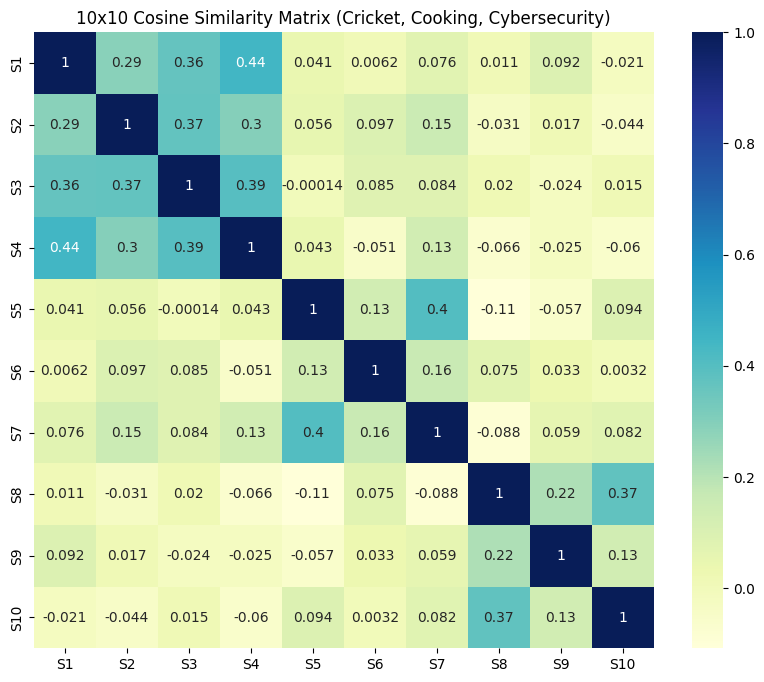

Query Sentence: 'The bowler took three wickets in one over'

Top 2 Most Similar Sentences:
- Score: 0.5549 | Sentence: The batsman hit a magnificent six over long-on.
- Score: 0.4117 | Sentence: The umpire signaled a wide after the ball passed well outside the off-stump.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Write 10 sentences across 3 topics
sentences = [
    # Topic: Cricket
    "The batsman hit a magnificent six over long-on.",
    "The leg-spinner bamboozled the striker with a googly.",
    "Fielding at slip requires immense concentration and quick reflexes.",
    "The umpire signaled a wide after the ball passed well outside the off-stump.",

    # Topic: Cooking
    "Slowly sauté the onions until they are translucent and golden brown.",
    "A pinch of saffron adds a distinct aroma and vibrant color to the biryani.",
    "Whisk the egg whites until stiff peaks form for a light soufflé.",

    # Topic: Cybersecurity
    "Multi-factor authentication significantly reduces the risk of unauthorized access.",
    "A zero-day vulnerability was discovered in the popular web browser.",
    "Encrypting sensitive data at rest is a fundamental security best practice."
]

# 2. Generate embeddings using sentence-transformers (all-MiniLM-L6-v2)
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

# 3. Compute and display a 10×10 cosine similarity matrix as a heatmap
sim_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, annot=True, cmap='YlGnBu',
            xticklabels=[f"S{i+1}" for i in range(10)],
            yticklabels=[f"S{i+1}" for i in range(10)])
plt.title("10x10 Cosine Similarity Matrix (Cricket, Cooking, Cybersecurity)")
plt.show()

# 4. Find the top 2 most similar sentences for a new query
query_sentence = "The bowler took three wickets in one over"
query_embedding = model.encode([query_sentence])

# Compute similarity between query and all stored sentences
similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get indices of the top 2 highest scores
top_2_indices = similarities.argsort()[-2:][::-1]

print(f"Query Sentence: '{query_sentence}'\n")
print("Top 2 Most Similar Sentences:")
for idx in top_2_indices:
    print(f"- Score: {similarities[idx]:.4f} | Sentence: {sentences[idx]}")